In [1]:
from cmath import nan

#zagruzka

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plot
from sklearn.linear_model import SGDClassifier

#сам набор данных
data = pd.read_csv("data/train.csv")
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


вывести первые 10 и последние 10 записей

In [2]:
data.tail(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
881,882,0,3,"Markun, Mr. Johann",male,33.0,0,0,349257,7.8958,NaN,S
882,883,0,3,"Dahlberg, Miss. Gerda Ulrika",female,22.0,0,0,7552,10.5167,NaN,S
883,884,0,2,"Banfield, Mr. Frederick James",male,28.0,0,0,C.A./SOTON 34068,10.5000,NaN,S
884,885,0,3,"Sutehall, Mr. Henry Jr",male,25.0,0,0,SOTON/OQ 392076,7.0500,NaN,S
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.7500,NaN,Q


In [3]:
data.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


посмотреть количество пропусков через isnull и sum

In [4]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<Axes: >

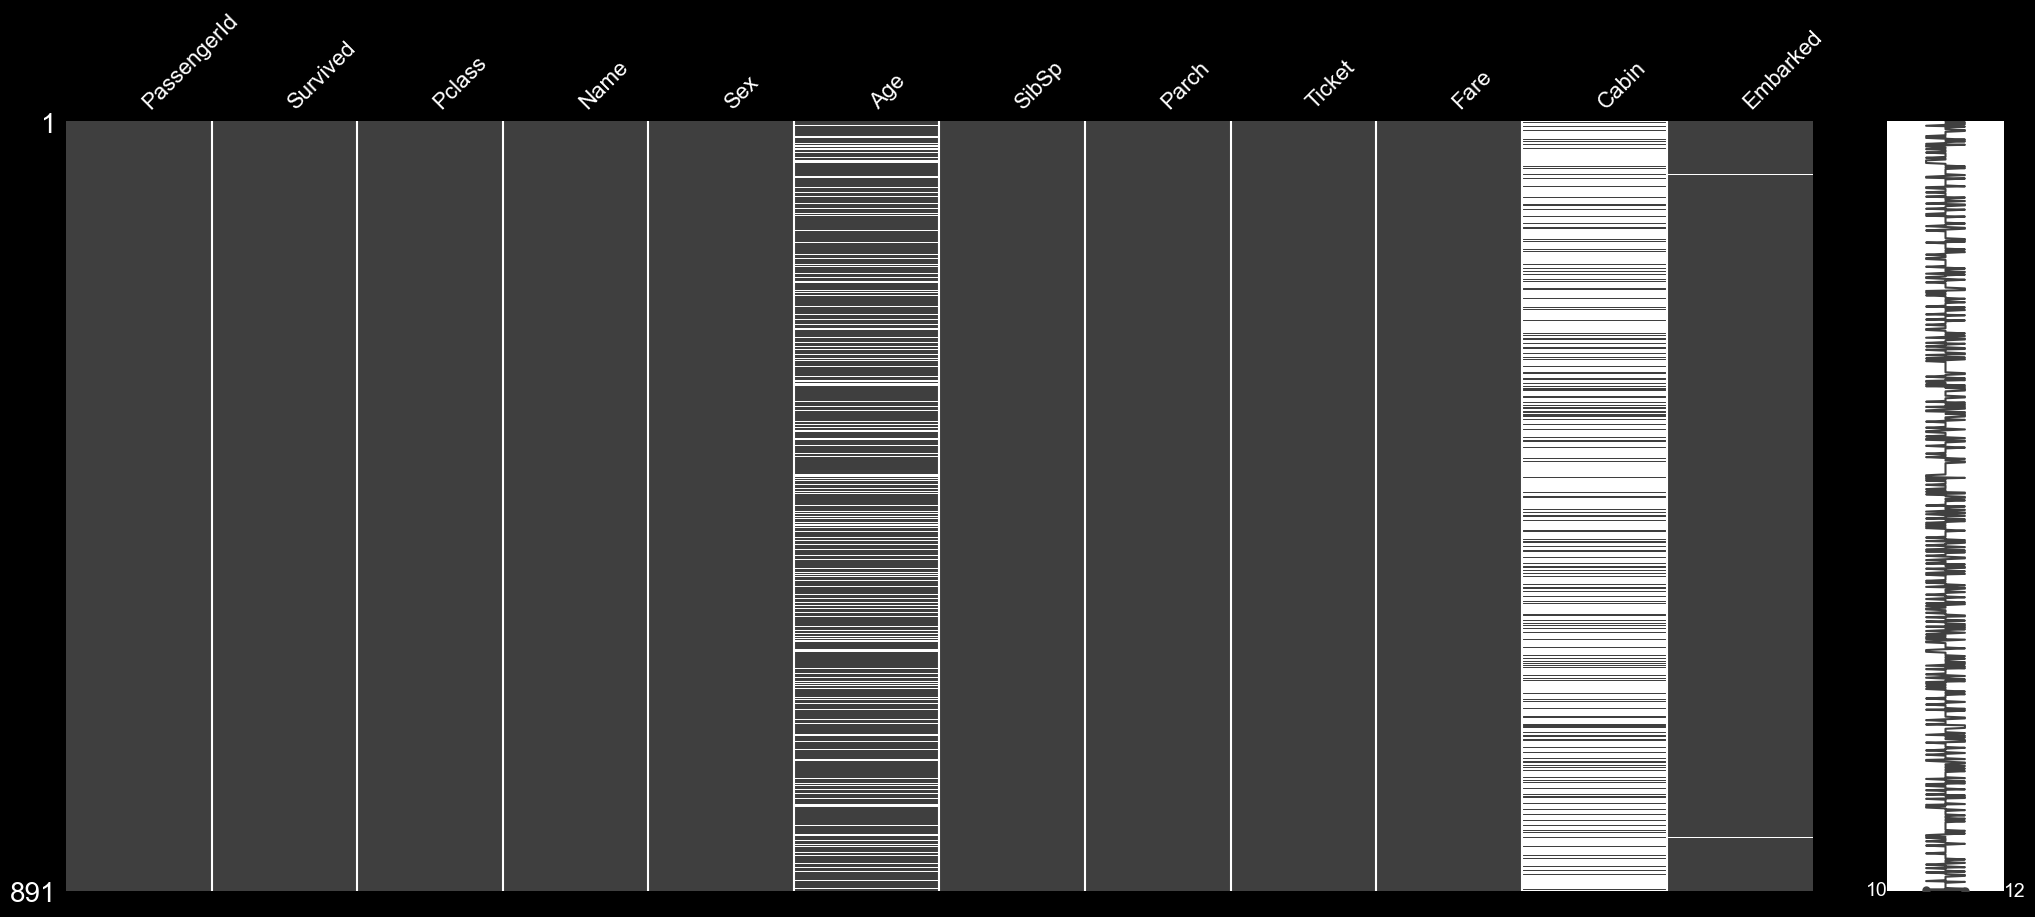

In [5]:
import missingno
missingno.matrix(data)

In [6]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
#describe остальных без age
temp_data = data.drop(columns=['Age'])
temp_data.describe()

,PassengerId,Survived,Pclass,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,8.000000,6.000000,512.329200


<Axes: xlabel='Sex', ylabel='count'>

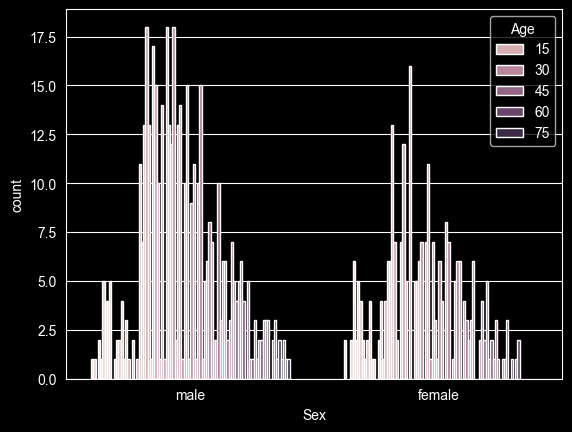

In [8]:
sns.countplot(hue=data.Age,x=data.Sex)

In [9]:
#sns.countplot(hue=data.Name,x=data.Sex) #проклято

<Axes: xlabel='Sex', ylabel='count'>

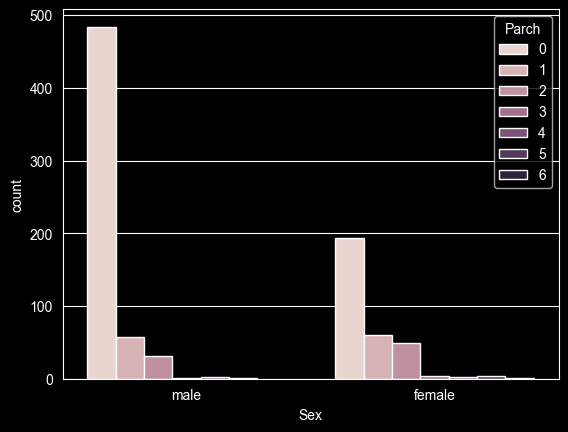

In [10]:
sns.countplot(hue=data.Parch,x=data.Sex)

<Axes: xlabel='Sex', ylabel='count'>

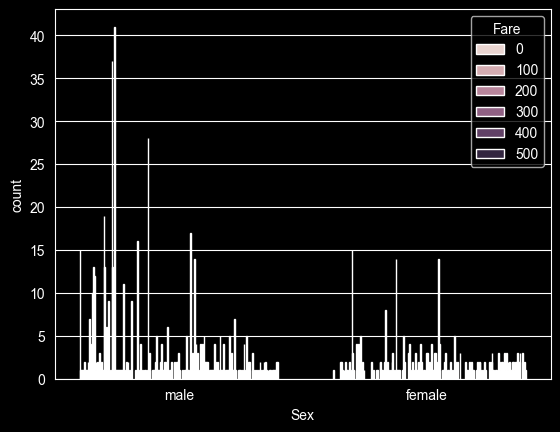

In [11]:
sns.countplot(hue=data.Fare,x=data.Sex)

<Axes: xlabel='Sex', ylabel='count'>

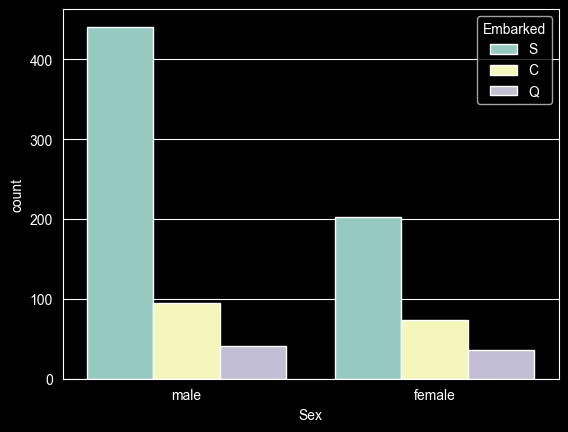

In [12]:
sns.countplot(hue=data.Embarked,x=data.Sex)

In [13]:
#sns.countplot(hue=data.Cabin,x=data.Sex) #проклято

In [14]:
#sns.countplot(hue=data.PassengerId,x=data.Sex) #проклято

<Axes: xlabel='Sex', ylabel='count'>

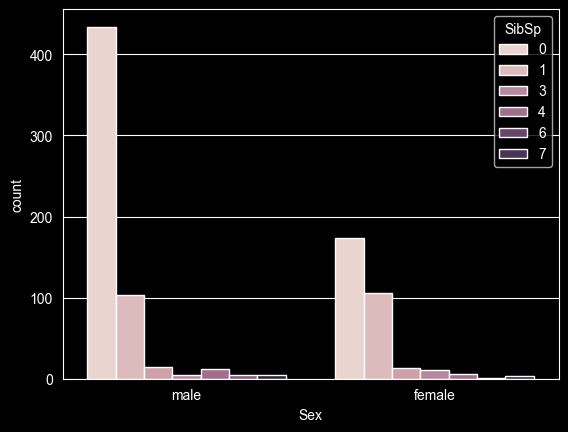

In [15]:
sns.countplot(hue=data.SibSp,x=data.Sex)

In [16]:
#sns.countplot(hue=data.Ticket,x=data.Sex)  #проклято

Проанализируйте выживаемость среди групп:
от 18 до 50,
от 50

<Axes: >

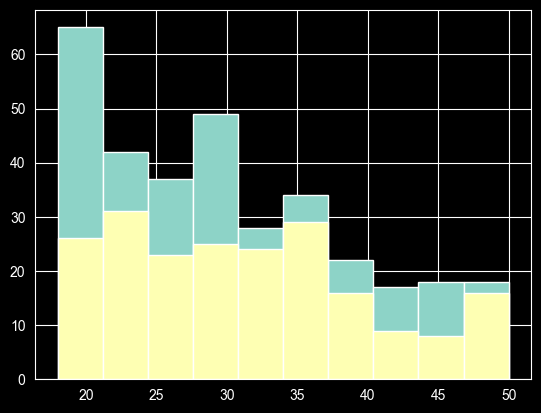

In [17]:
data.loc[((data['Survived'] == 0) & ( 50 >= data["Age"] ) & ( 18 <= data["Age"]))].Age.hist()
data.loc[((data['Survived'] == 1) & ( 50 >= data["Age"] ) & ( 18 <= data["Age"]))].Age.hist()

<Axes: >

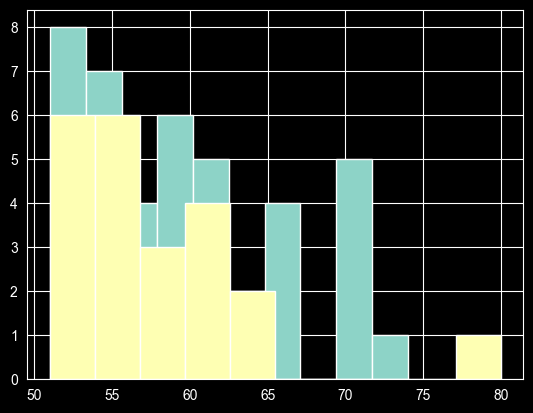

In [18]:
data.loc[((data['Survived'] == 0) & ( 50 < data["Age"] ))].Age.hist()
data.loc[((data['Survived'] == 1) & ( 50 < data["Age"] ))].Age.hist()

Проанализируйте подробно выживаемость:
1) Пассажиры с дети >= 2
2) Пассажиры с дети <= 2 & > 0
3) Пассажиры с дети == 0

<Axes: >

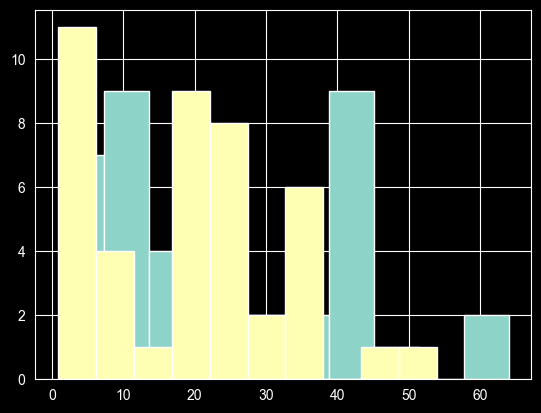

In [19]:
data.loc[((data['Survived'] == 0) & (data["Parch"] >= 2))].Age.hist()
data.loc[((data['Survived'] == 1) & (data["Parch"] >= 2))].Age.hist()

<Axes: >

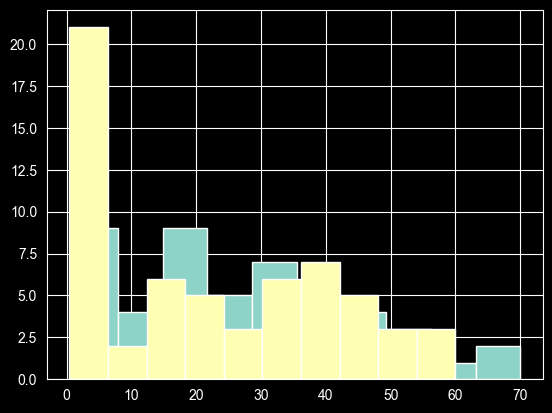

In [20]:
data.loc[((data['Survived'] == 0) & (data["Parch"] < 2) & (data["Parch"] > 0))].Age.hist()
data.loc[((data['Survived'] == 1) & (data["Parch"] < 2) & (data["Parch"] > 0))].Age.hist()

<Axes: >

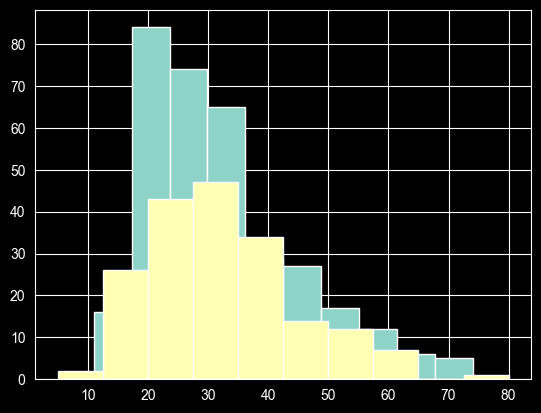

In [21]:
data.loc[((data['Survived'] == 0) & (data["Parch"] == 0))].Age.hist()
data.loc[((data['Survived'] == 1) & (data["Parch"] == 0))].Age.hist()

Проанализировать выживаемость:
1) Больше 2х сестер
2) 2 > Сестер > 0
3) Сестер == 0

<Axes: >

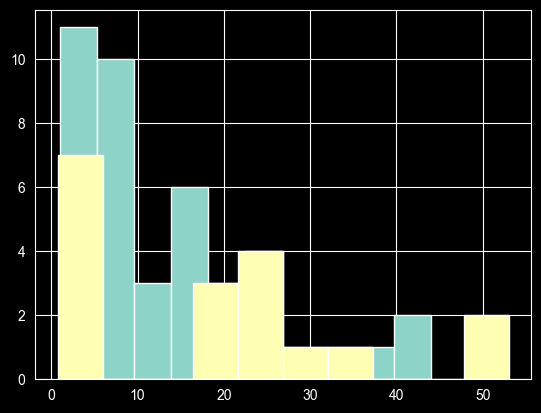

In [22]:
data.loc[((data['Survived'] == 0) & (data["SibSp"] >= 2))].Age.hist()
data.loc[((data['Survived'] == 1) & (data["SibSp"] >= 2))].Age.hist()

<Axes: >

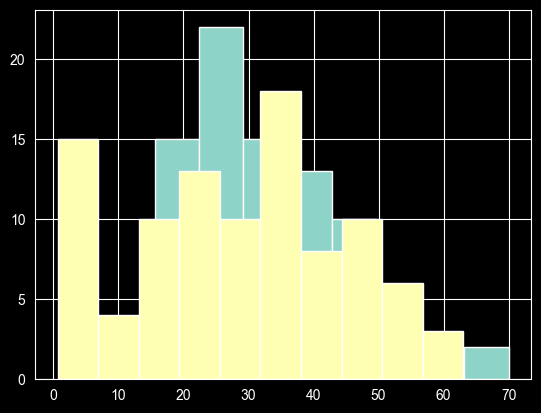

In [23]:
data.loc[((data['Survived'] == 0) & (data["SibSp"] < 2) & (data["SibSp"] > 0))].Age.hist()
data.loc[((data['Survived'] == 1) & (data["SibSp"] < 2) & (data["SibSp"] > 0))].Age.hist()

<Axes: >

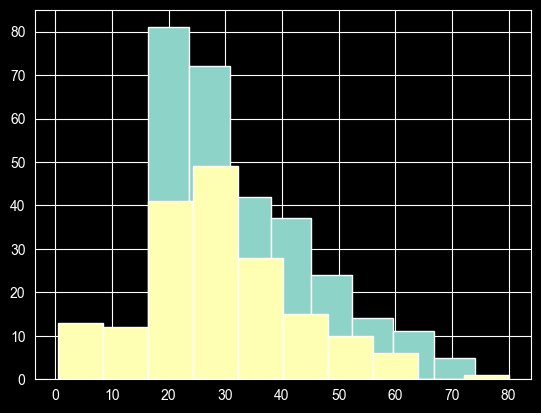

In [24]:
data.loc[((data['Survived'] == 0) & (data["SibSp"] == 0))].Age.hist()
data.loc[((data['Survived'] == 1) & (data["SibSp"] == 0))].Age.hist()

Выполните замену в каждой группе (мужчин и женщин)\
Восстановите возраст\
Выделите несколько групп (Mr, Mrs, Miss и тп) которые тесно коррелируют с возрастом


In [25]:
print(data.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [26]:
#data.Name # Miss, Mrs, Mr, empty or uniq
miss_data = data[data['Name'].str.contains("Miss.")]
mrs_data = data[data['Name'].str.contains("Mrs. ")]
mr_data = data[data['Name'].str.contains("Mr. ")]
strange_data = data[~data['Name'].str.contains('Mr. | Mrs. | Miss. ')]

miss_data.loc[(pd.isna(miss_data.Age)),'Age'] = miss_data.Age.median()
mrs_data.loc[(pd.isna(mrs_data.Age)),'Age'] = mrs_data.Age.median()
strange_data.loc[(pd.isna(strange_data.Age)),'Age'] = strange_data.Age.median()
mr_data.loc[(pd.isna(mr_data.Age)),'Age'] = mr_data.Age.median()

strange_data


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.00,3,1,349909,21.0750,NaN,S
16,17,0,3,"Rice, Master. Eugene",male,2.00,4,1,382652,29.1250,NaN,Q
30,31,0,1,"Uruchurtu, Don. Manuel E",male,40.00,0,0,PC 17601,27.7208,NaN,C
50,51,0,3,"Panula, Master. Juha Niilo",male,7.00,4,1,3101295,39.6875,NaN,S
59,60,0,3,"Goodwin, Master. William Frederick",male,11.00,5,2,CA 2144,46.9000,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
831,832,1,2,"Richards, Master. George Sibley",male,0.83,1,1,29106,18.7500,NaN,S
848,849,0,2,"Harper, Rev. John",male,28.00,0,1,248727,33.0000,NaN,S
850,851,0,3,"Andersson, Master. Sigvard Harald Elias",male,4.00,4,2,347082,31.2750,NaN,S
869,870,1,3,"Johnson, Master. Harold Theodor",male,4.00,1,1,347742,11.1333,NaN,S


<Axes: >

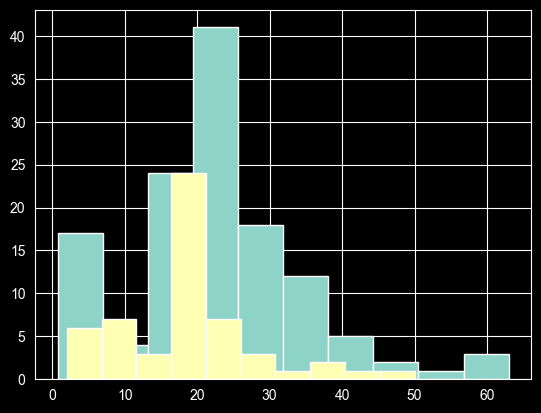

In [27]:
miss_data.loc[(data['Survived'] == 1)].Age.hist()
miss_data.loc[(data['Survived'] == 0)].Age.hist()

<Axes: >

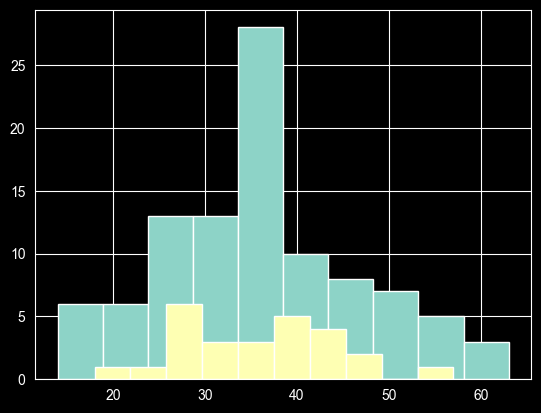

In [28]:
mrs_data.loc[(data['Survived'] == 1)].Age.hist()
mrs_data.loc[(data['Survived'] == 0)].Age.hist()

<Axes: >

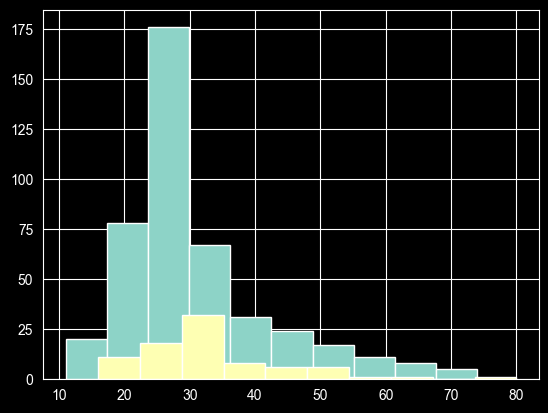

In [29]:
mr_data.loc[(data['Survived'] == 0)].Age.hist()
mr_data.loc[(data['Survived'] == 1)].Age.hist()

<Axes: >

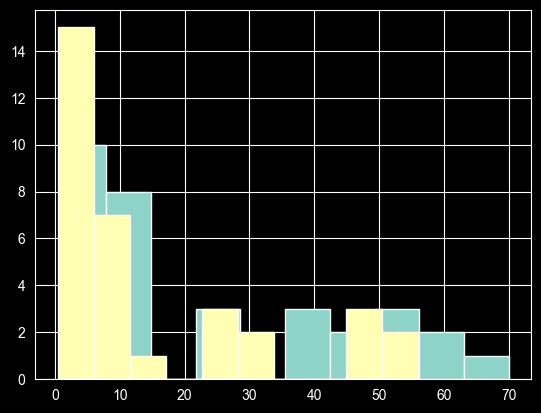

In [30]:
strange_data.loc[(data['Survived'] == 0)].Age.hist()
strange_data.loc[(data['Survived'] == 1)].Age.hist()

Выполнить анализ выживаемости от наличия номера каюты\
Заменить категориальный признак на бинарный (есть номер каюты или нет)

<Axes: xlabel='Survived', ylabel='count'>

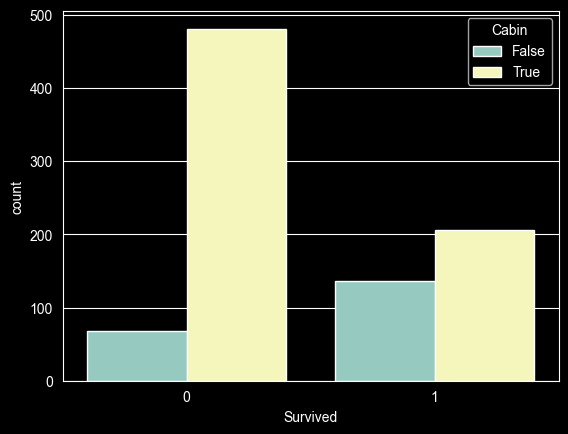

In [31]:
sns.countplot(hue=data['Cabin'].isnull(),x=data.Survived)

In [32]:
miss_med = miss_data.Age.median()
mrs_med = mrs_data.Age.median()
mr_med = mr_data.Age.median()
strange_med = strange_data.Age.median()



data.loc[data['Name'].str.contains('Mrs. ') & ((data['Age'] == 0) | data['Age'].isnull()),'Age'] = mrs_med
data.loc[data['Name'].str.contains('Miss. ') &((data['Age'] == 0) | data['Age'].isnull()),'Age'] = miss_med
data.loc[data['Name'].str.contains('Mr. ') & ((data['Age'] == 0) | data['Age'].isnull()),'Age'] = mrs_med
data.loc[~data['Name'].str.contains('Mrs. | Mr. | Miss. ') & ((data['Age'] == 0) | data['Age'].isnull()),'Age'] = strange_med

data.loc[data['Embarked'].isnull()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN


<Axes: >

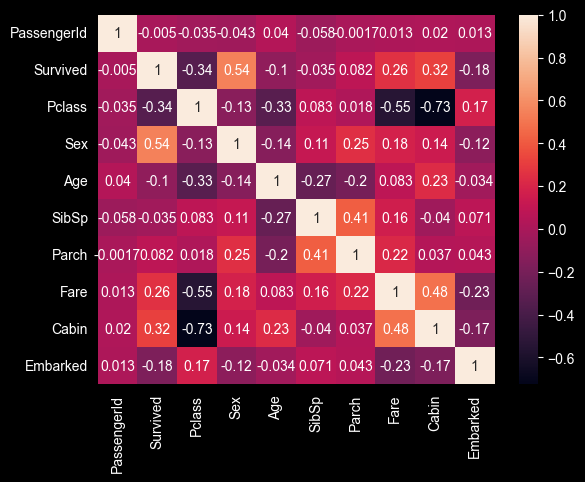

In [33]:


mod_data = data.drop(['Name','Ticket'], axis=1)
sex = {'male':0, 'female':1}
embarked = {'S':3,'C':1,'Q':2,np.nan:0}
mod_data['Sex'] = mod_data['Sex'].map(sex)
mod_data['Embarked'] = mod_data['Embarked'].map(embarked)
mod_data['Cabin'] = mod_data['Cabin'].notna().astype(int)



sns.heatmap(mod_data.corr(),annot=True)


Построить матрицу корреляции по признакам, связанными с родственниками

<Axes: >

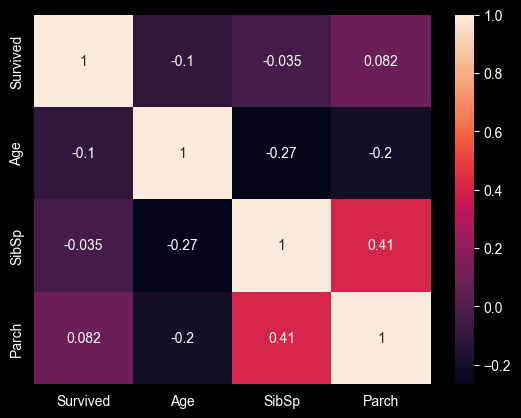

In [34]:
sns.heatmap(mod_data[['Survived','Age','SibSp','Parch']].corr(),annot=True)

Стоимость билета - хороший признак\
Проанализируйте этот параметр\
заменим билеты с нулевой стоимостью на медианную стоимость соотв класса


In [35]:
med_price = {1:mod_data.where(mod_data.Pclass == 1).Fare.median(),
             2:mod_data.where(mod_data.Pclass == 2).Fare.median(),
             3:mod_data.where(data.Pclass == 3).Fare.median()}
mod_data.loc[mod_data['Fare'] == 0,'Fare'] = mod_data['Pclass'].map(med_price)

Проанализировать зависимость выживаемости от стоимости билета

<Axes: >

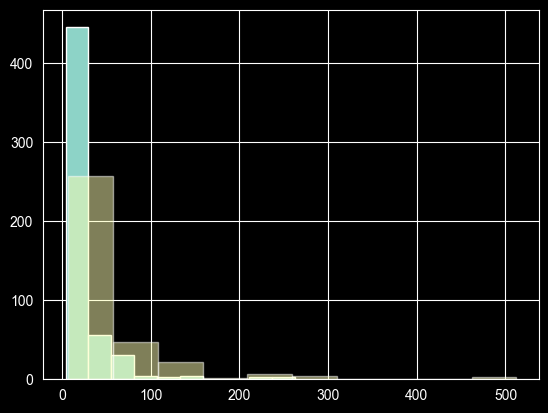

In [36]:
mod_data.loc[data['Survived'] == 0].Fare.hist()
mod_data.loc[data['Survived'] == 1].Fare.hist(alpha=0.5)

<Axes: >

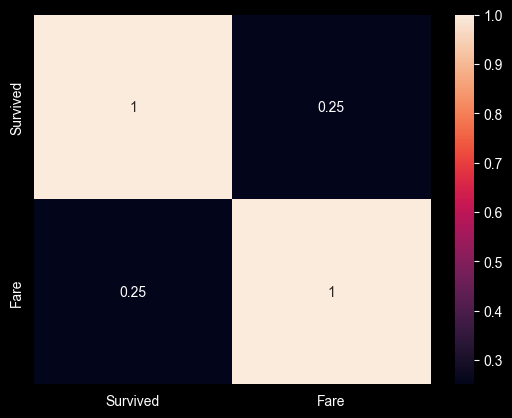

In [37]:
sns.heatmap(mod_data[['Survived','Fare']].corr(),annot=True)

# Лабораторная номер 5

In [38]:
mod_data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Sex            0
Age            0
SibSp          0
Parch          0
Fare           0
Cabin          0
Embarked       0
dtype: int64

In [39]:
mod_data

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,1,0,3,0,22.0,1,0,7.2500,0,3
1,2,1,1,1,38.0,1,0,71.2833,1,1
2,3,1,3,1,26.0,0,0,7.9250,0,3
3,4,1,1,1,35.0,1,0,53.1000,1,3
4,5,0,3,0,35.0,0,0,8.0500,0,3
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,0,27.0,0,0,13.0000,0,3
887,888,1,1,1,19.0,0,0,30.0000,1,3
888,889,0,3,1,21.0,1,2,23.4500,0,3
889,890,1,1,0,26.0,0,0,30.0000,1,1


# Построим матрицу корреляции

<Axes: >

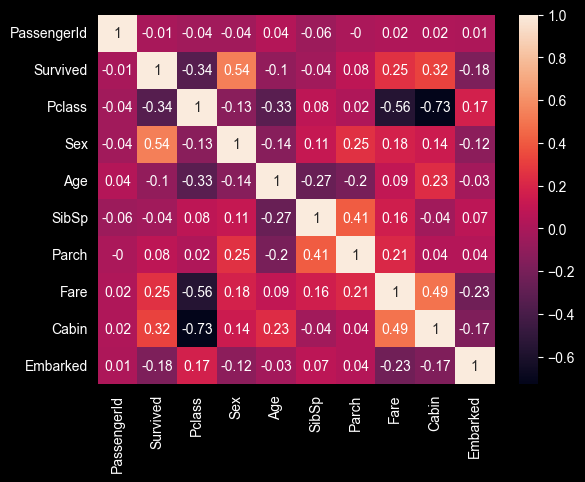

In [40]:
mdc = mod_data.corr().round(2)
sns.heatmap(data=mdc,annot=True)

# Выделим целевой признак

In [41]:
Y = mod_data['Survived']
Y

0      0
1      1
2      1
3      1
4      0
      ..
886    0
887    1
888    0
889    1
890    0
Name: Survived, Length: 891, dtype: int64

# Остальное

In [42]:
X = mod_data.drop(['Survived'], axis=1)
X

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Embarked
0,1,3,0,22.0,1,0,7.2500,0,3
1,2,1,1,38.0,1,0,71.2833,1,1
2,3,3,1,26.0,0,0,7.9250,0,3
3,4,1,1,35.0,1,0,53.1000,1,3
4,5,3,0,35.0,0,0,8.0500,0,3
...,...,...,...,...,...,...,...,...,...
886,887,2,0,27.0,0,0,13.0000,0,3
887,888,1,1,19.0,0,0,30.0000,1,3
888,889,3,1,21.0,1,2,23.4500,0,3
889,890,1,0,26.0,0,0,30.0000,1,1


# Загрузим данные для теста

In [43]:
test_data = pd.read_csv('data/test.csv',index_col='PassengerId')
test_data.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age          86
SibSp         0
Parch         0
Ticket        0
Fare          1
Cabin       327
Embarked      0
dtype: int64

# Выполним обработку

In [44]:
#возраст по префиксу
test_data.loc[test_data['Name'].str.contains('Mrs. ') &  test_data['Age'].isnull(),'Age'] = (
    test_data.loc[test_data['Name'].str.contains('Mrs. ')].Age.median())
test_data.loc[test_data['Name'].str.contains('Mr. ') &  test_data['Age'].isnull(),'Age'] = (
    test_data.loc[test_data['Name'].str.contains('Mr. ')].Age.median())
test_data.loc[test_data['Name'].str.contains('Miss. ') &  test_data['Age'].isnull(),'Age'] = (
    test_data.loc[test_data['Name'].str.contains('Miss. ')].Age.median())
test_data.loc[~test_data['Name'].str.contains('Mrs. |Mr. |Miss. ') &  test_data['Age'].isnull(),'Age'] = (
    test_data.loc[~test_data['Name'].str.contains('Mrs. |Mr. |Miss. ')].Age.median())

#наличие/отсутствие каюты и замена пола на бинарный

embarked = {'S':3,'C':1,'Q':2,np.nan:0}
sex = {'male':0, 'female':1}
test_data['Sex'] = test_data['Sex'].map(sex)
test_data['Embarked'] = test_data['Embarked'].map(embarked)
test_data['Cabin'] = test_data['Cabin'].notna().astype(int)

#восстановление цены
test_med_price = {1:test_data.where(test_data.Pclass == 1).Fare.median(),
             2:test_data.where(test_data.Pclass == 2).Fare.median(),
             3:test_data.where(test_data.Pclass == 3).Fare.median()}
test_data.loc[(test_data['Fare'] == 0) | (test_data['Fare'].isnull()),'Fare'] = test_data['Pclass'].map(test_med_price)

test_data.isnull().sum()

Survived    0
Pclass      0
Name        0
Sex         0
Age         0
SibSp       0
Parch       0
Ticket      0
Fare        0
Cabin       0
Embarked    0
dtype: int64

# Временно разделим тренировачный датасет

In [45]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.1,random_state=5)
X_train.shape

(801, 9)

# Создадим модель DecisionTree

In [46]:
from sklearn.tree import DecisionTreeClassifier
dtf = DecisionTreeClassifier(random_state=0)
dtf.fit(X_train,Y_train)
pred_1 = dtf.predict(X_test)

# Построим матрицу ошибки

In [47]:
df1 = pd.crosstab(Y_test, pred_1)
df1

col_0,0,1
Survived,,
0,44,10
1,12,24


# Выполним оценку

In [48]:
from sklearn.metrics import accuracy_score,precision_score,recall_score

print('accuracy_score: ',accuracy_score(Y_test,pred_1))
print('precision_score: ',precision_score(Y_test,pred_1))
print('recall_score: ',recall_score(Y_test,pred_1))

accuracy_score:  0.7555555555555555
precision_score:  0.7058823529411765
recall_score:  0.6666666666666666


# Общий отчет (проанализируйте результат)

In [49]:
from sklearn.metrics import classification_report

print(classification_report(Y_test,pred_1))

              precision    recall  f1-score   support

           0       0.79      0.81      0.80        54
           1       0.71      0.67      0.69        36

    accuracy                           0.76        90
   macro avg       0.75      0.74      0.74        90
weighted avg       0.75      0.76      0.75        90



# Построим кривые ROC

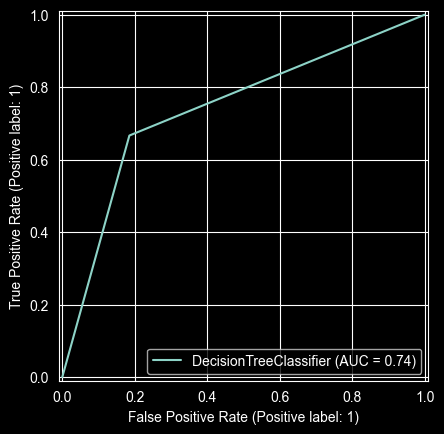

In [50]:
from sklearn.metrics import RocCurveDisplay

dtf_disp = RocCurveDisplay.from_estimator(dtf, X_test, Y_test,)
plot.show()

# 5 других моделей

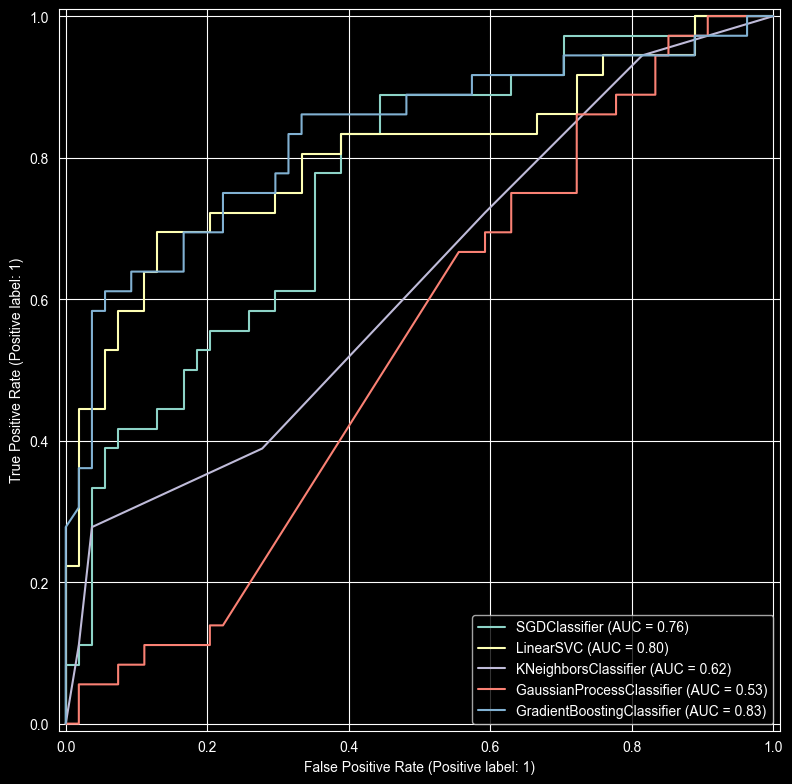

In [51]:
from sklearn import linear_model
from sklearn import svm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

fig, ax = plot.subplots(figsize=(8,8))

#sp = plot.subplot(2,3,1)
sgd = linear_model.SGDClassifier(random_state=0)
sgd.fit(X_train,Y_train)
pred_sgd = sgd.predict(X_test)
disp1 = RocCurveDisplay.from_estimator(sgd, X_test, Y_test,ax=ax)

#sp = plot.subplot(2,3,2)
lsvc = svm.LinearSVC(random_state=0)
lsvc.fit(X_train,Y_train)
pred_lsvc = lsvc.predict(X_test)
disp2 = RocCurveDisplay.from_estimator(lsvc, X_test, Y_test,ax=ax)

#sp = plot.subplot(2,3,3)
knc = KNeighborsClassifier()
knc.fit(X_train,Y_train)
pred_knc = knc.predict(X_test)
disp3 = RocCurveDisplay.from_estimator(knc, X_test, Y_test,ax=ax)

#sp = plot.subplot(2,3,4)
gpc = GaussianProcessClassifier(random_state=0)
gpc.fit(X_train,Y_train)
pred_gpc = gpc.predict(X_test)
disp4 = RocCurveDisplay.from_estimator(gpc, X_test, Y_test,ax=ax)

#sp = plot.subplot(2,3,5)
gbc = GradientBoostingClassifier(random_state=0)
gbc.fit(X_train,Y_train)
pred_gbc = gbc.predict(X_test)
disp5 = RocCurveDisplay.from_estimator(gbc, X_test, Y_test,ax=ax)



plot.tight_layout()
plot.show()

# Обучите модели на полном наборе (для тестирования отдельный набор)
(хотя мы вроде и так полный набор используем)

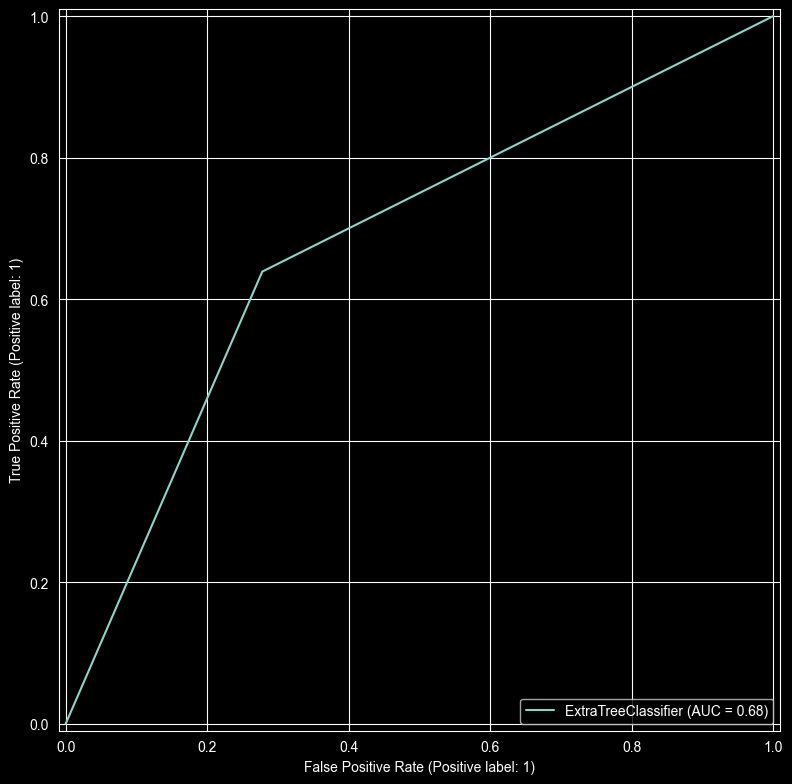

accuracy_score:  0.6888888888888889
precision_score:  0.6052631578947368
recall_score:  0.6388888888888888


In [52]:
from sklearn.tree import ExtraTreeClassifier

fig, ax = plot.subplots(figsize=(8,8))

etc = ExtraTreeClassifier(random_state=0)
etc.fit(X_train,Y_train)
pred_etc = etc.predict(X_test)
disp4 = RocCurveDisplay.from_estimator(etc, X_test, Y_test,ax=ax)

plot.tight_layout()
plot.show()

print('accuracy_score: ',accuracy_score(Y_test,pred_etc))
print('precision_score: ',precision_score(Y_test,pred_etc))
print('recall_score: ',recall_score(Y_test,pred_etc))

# Уменьшите количество признаков (по матрице кореляции).
# Проанализировать результаты на новых моделях

<Axes: >

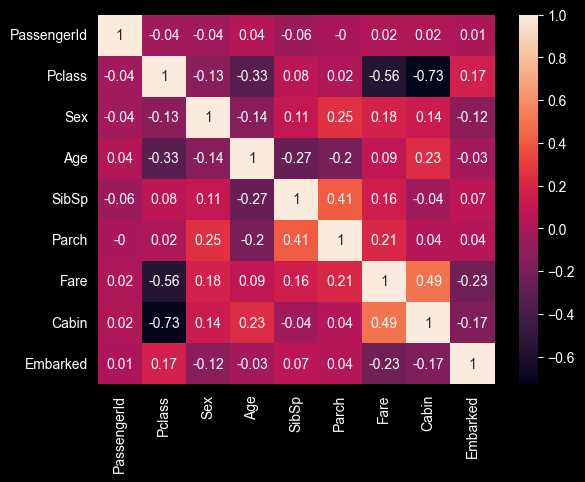

In [53]:
xc = X.corr().round(2)
sns.heatmap(data=xc,annot=True)

<Axes: >

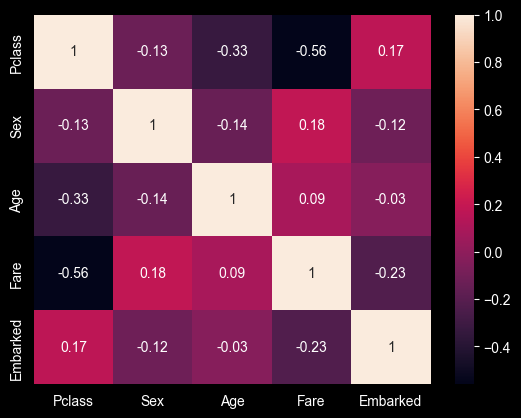

In [54]:
X_fewer = X.drop(['SibSp','Parch','PassengerId','Cabin'],axis=1)
xfc = X_fewer.corr().round(2)
sns.heatmap(data=xfc,annot=True)

# Разделим данные и снова построим модель с анализом

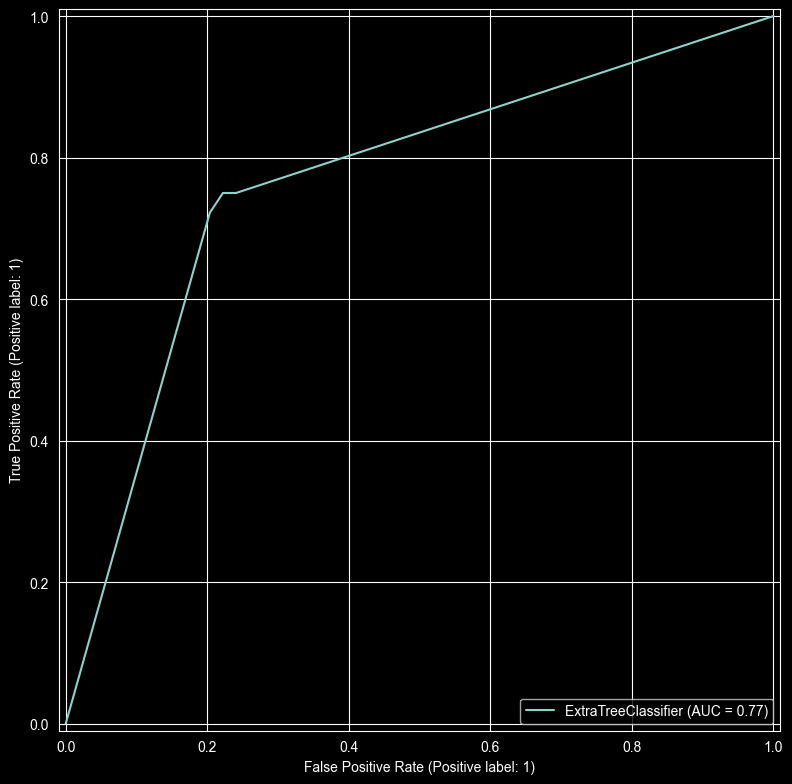

accuracy_score:  0.7666666666666667
precision_score:  0.7027027027027027
recall_score:  0.7222222222222222


In [55]:
Xf_train, Xf_test, Yf_train, Yf_test = train_test_split(X_fewer,Y,test_size = 0.1,random_state=5)

fig, ax = plot.subplots(figsize=(8,8))

etcf = ExtraTreeClassifier(random_state=0)
etcf.fit(Xf_train,Yf_train)
pred_f_etc = etcf.predict(Xf_test)
disp4 = RocCurveDisplay.from_estimator(etcf, Xf_test, Yf_test,ax=ax)

plot.tight_layout()
plot.show()

print('accuracy_score: ',accuracy_score(Yf_test,pred_f_etc))
print('precision_score: ',precision_score(Yf_test,pred_f_etc))
print('recall_score: ',recall_score(Yf_test,pred_f_etc))

# Увеличим количество признаков (также проанализируем и построим)

In [56]:
from sklearn.preprocessing import PolynomialFeatures

print(X.shape)

Xl = PolynomialFeatures(include_bias=False).fit_transform(X)
print(Xl.shape)


(891, 9)
(891, 54)


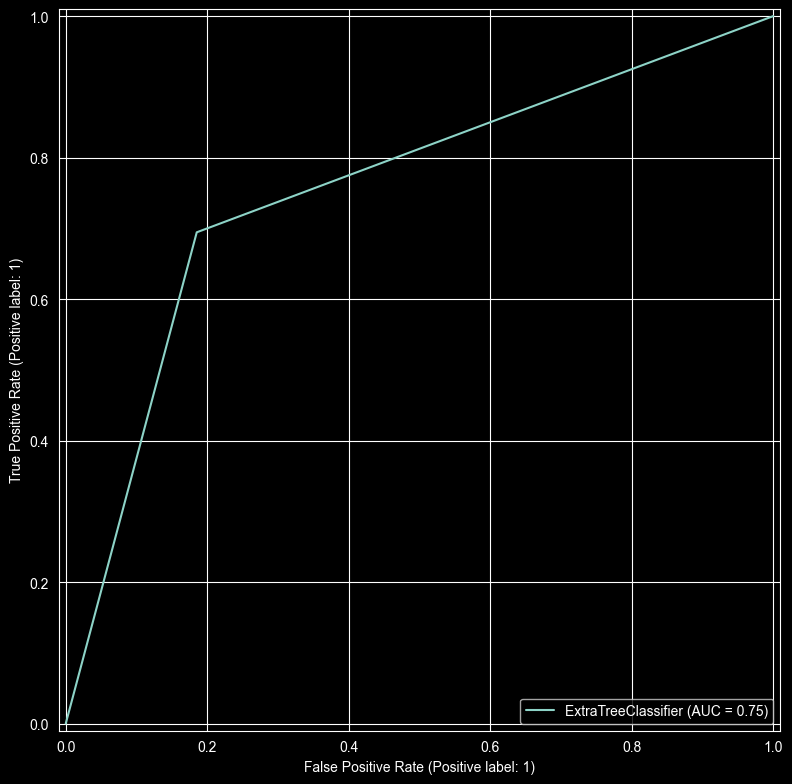

accuracy_score:  0.7666666666666667
precision_score:  0.7142857142857143
recall_score:  0.6944444444444444


In [57]:
Xl_train, Xl_test, Yl_train, Yl_test = train_test_split(Xl,Y,test_size = 0.1,random_state=5)

fig, ax = plot.subplots(figsize=(8,8))

etcl = ExtraTreeClassifier(random_state=0)
etcl.fit(Xl_train,Yl_train)
pred_l_etc = etcl.predict(Xl_test)
disp4 = RocCurveDisplay.from_estimator(etcl, Xl_test, Yl_test,ax=ax)

plot.tight_layout()
plot.show()

print('accuracy_score: ',accuracy_score(Yl_test,pred_l_etc))
print('precision_score: ',precision_score(Yl_test,pred_l_etc))
print('recall_score: ',recall_score(Yl_test,pred_l_etc))

# Выбрал датасет на каггл
отсортировал по binary и csv, выбрал первый\
https://www.kaggle.com/datasets/nimapourmoradi/raisin-binary-classification

In [58]:
raisin = pd.read_csv('data/Raisin_Dataset.csv')
raisin

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen
...,...,...,...,...,...,...,...,...
895,83248,430.077308,247.838695,0.817263,85839,0.668793,1129.072,Besni
896,87350,440.735698,259.293149,0.808629,90899,0.636476,1214.252,Besni
897,99657,431.706981,298.837323,0.721684,106264,0.741099,1292.828,Besni
898,93523,476.344094,254.176054,0.845739,97653,0.658798,1258.548,Besni


<Axes: >

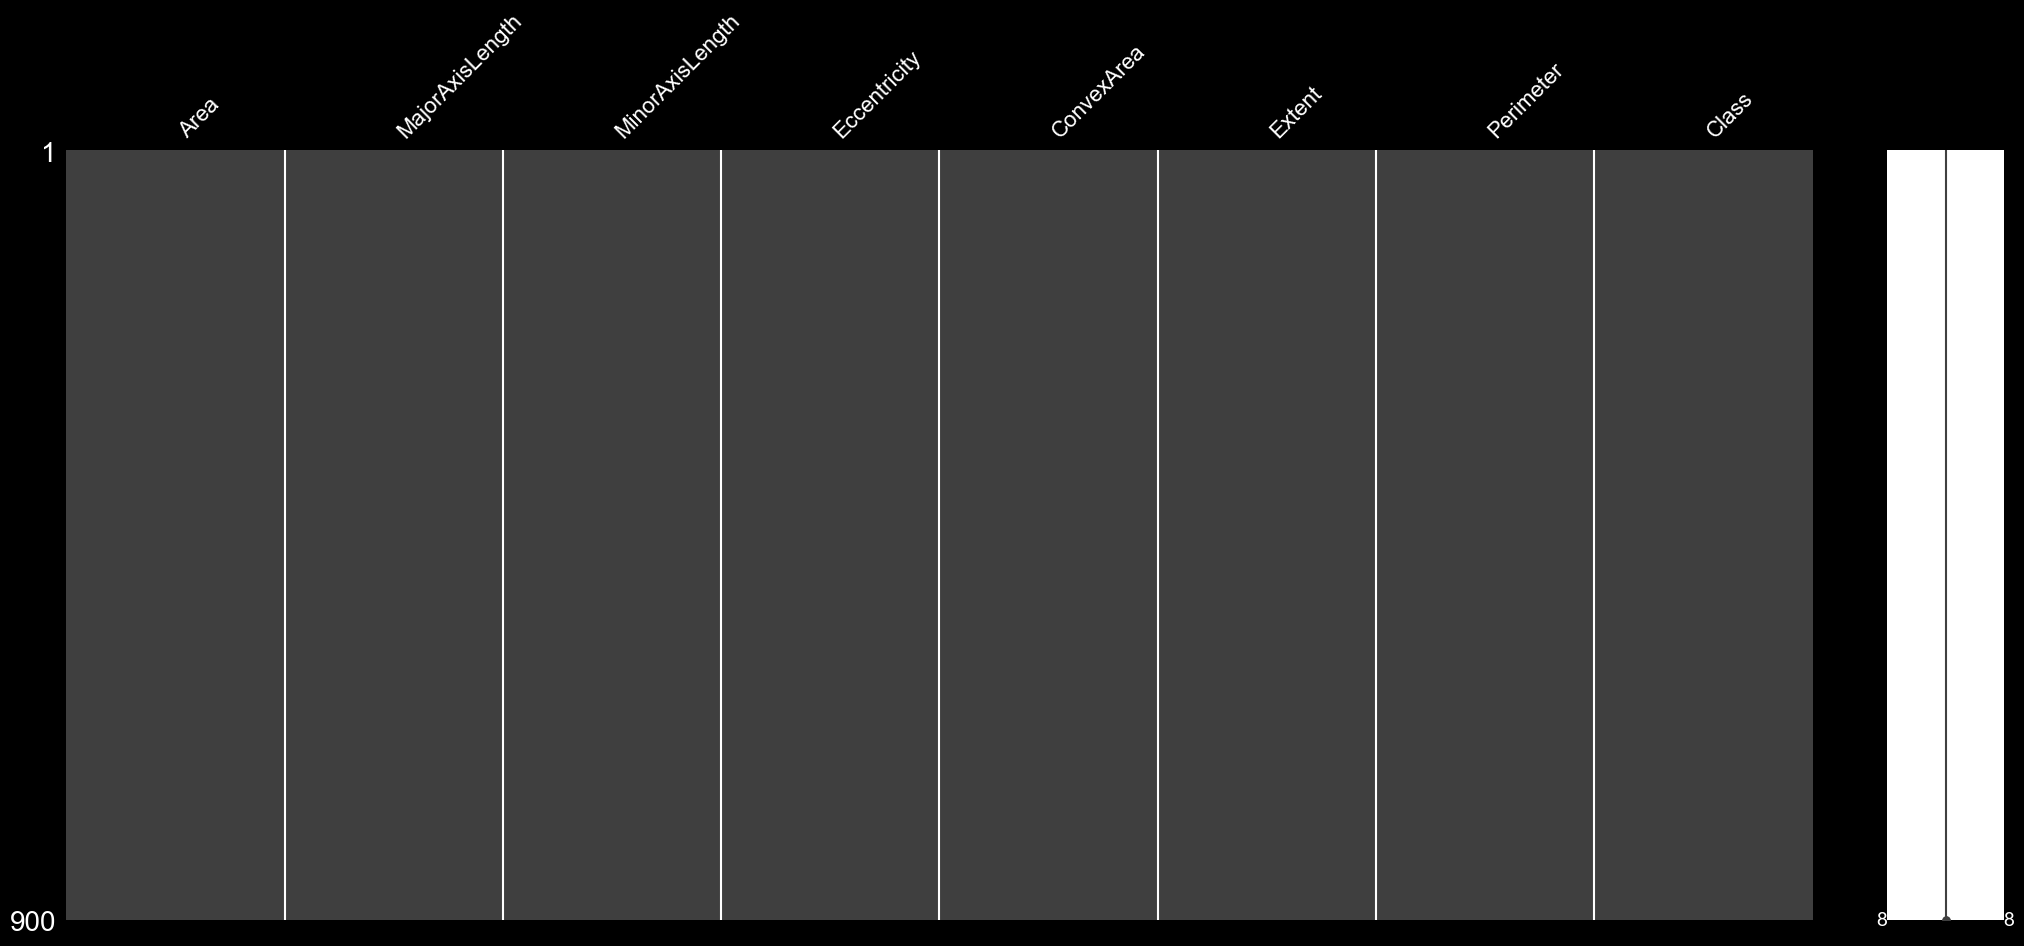

In [59]:
missingno.matrix(raisin)

In [60]:
print(raisin['Class'].unique())
classes = {"Kecimen":1 ,'Besni': 2}
raisin['Class'] = raisin['Class'].map(classes)
raisin

<StringArray>
['Kecimen', 'Besni']
Length: 2, dtype: str


,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,1
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,1
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,1
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,1
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,1
...,...,...,...,...,...,...,...,...
895,83248,430.077308,247.838695,0.817263,85839,0.668793,1129.072,2
896,87350,440.735698,259.293149,0.808629,90899,0.636476,1214.252,2
897,99657,431.706981,298.837323,0.721684,106264,0.741099,1292.828,2
898,93523,476.344094,254.176054,0.845739,97653,0.658798,1258.548,2


<Axes: >

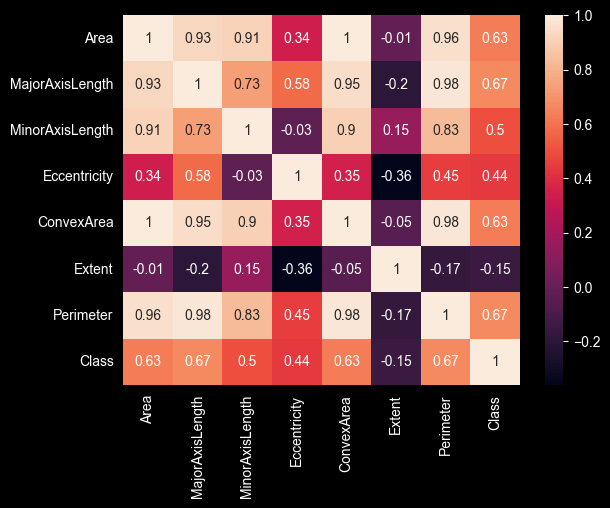

In [61]:
raisin_cor = raisin.corr().round(2)
sns.heatmap(data=raisin_cor,annot=True)

In [62]:
raisin.describe()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,87804.127778,430.929950,254.488133,0.781542,91186.090000,0.699508,1165.906636,1.500000
std,39002.111390,116.035121,49.988902,0.090318,40769.290132,0.053468,273.764315,0.500278
min,25387.000000,225.629541,143.710872,0.348730,26139.000000,0.379856,619.074000,1.000000
25%,59348.000000,345.442898,219.111126,0.741766,61513.250000,0.670869,966.410750,1.000000
50%,78902.000000,407.803951,247.848409,0.798846,81651.000000,0.707367,1119.509000,1.500000
75%,105028.250000,494.187014,279.888575,0.842571,108375.750000,0.734991,1308.389750,2.000000
max,235047.000000,997.291941,492.275279,0.962124,278217.000000,0.835455,2697.753000,2.000000


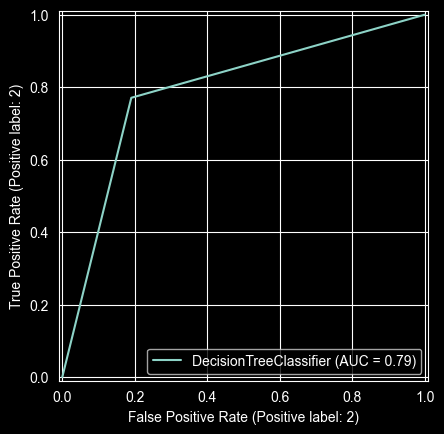

accuracy_score:  0.7888888888888889
precision_score:  0.7555555555555555
recall_score:  0.8095238095238095


In [63]:
raisin_Y = raisin['Class']
raisin_X = raisin.drop(['Class'],axis=1)

fig, ax = plot.subplots()

raisin_x_train,raisin_x_test,raisin_y_train,raisin_y_test = train_test_split(raisin_X,raisin_Y,test_size = 0.1,random_state=5)

raisin_dtf = DecisionTreeClassifier(random_state=0)
raisin_dtf.fit(raisin_x_train,raisin_y_train)
raisin_pred = raisin_dtf.predict(raisin_x_test)

disp4 = RocCurveDisplay.from_estimator(raisin_dtf, raisin_x_test, raisin_y_test,ax=ax)

plot.show()

print('accuracy_score: ',accuracy_score(raisin_y_test,raisin_pred))
print('precision_score: ',precision_score(raisin_y_test,raisin_pred))
print('recall_score: ',recall_score(raisin_y_test,raisin_pred))

# LAB 6 (Подпор гиперпараметров)

### Создадим модель DTree, построим матрицу ошибок

In [64]:
dtf = DecisionTreeClassifier(random_state=0)
dtf.fit(X_train,Y_train)
pred_1 = dtf.predict(X_test)

df1 = pd.crosstab(Y_test,pred_1)
df1

col_0,0,1
Survived,,
0,44,10
1,12,24


In [65]:
print('accuracy_score: ',accuracy_score(Y_test,pred_1))
print('precision_score: ',precision_score(Y_test,pred_1))
print('recall_score: ',recall_score(Y_test,pred_1))

accuracy_score:  0.7555555555555555
precision_score:  0.7058823529411765
recall_score:  0.6666666666666666


In [66]:
from sklearn.metrics import classification_report

print(classification_report(Y_test,pred_1))

              precision    recall  f1-score   support

           0       0.79      0.81      0.80        54
           1       0.71      0.67      0.69        36

    accuracy                           0.76        90
   macro avg       0.75      0.74      0.74        90
weighted avg       0.75      0.76      0.75        90



## Выводим важность признаков этой модели

In [67]:
dtf.feature_importances_

array([0.19030332, 0.07633813, 0.30630913, 0.15025049, 0.0614521 ,
       0.01386742, 0.15905399, 0.03291925, 0.00950618])

## Строим дерево

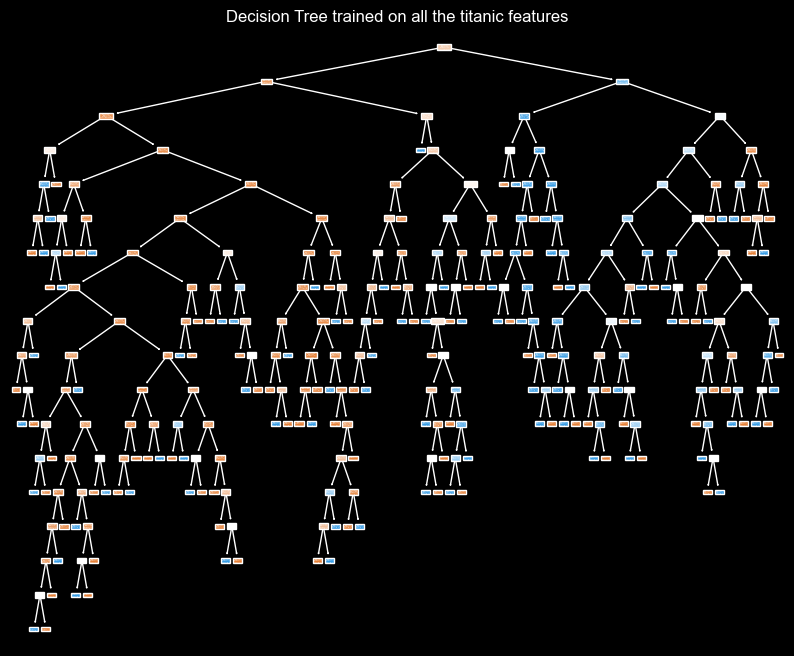

In [68]:
from sklearn.tree import plot_tree

plot.figure(figsize=(10,8))
plot_tree(dtf,filled=True)
plot.title('Decision Tree trained on all the titanic features')
plot.show()

## Подберем оптимальные гиперпараметры

In [69]:
param_grid = {
    'splitter':['best','random'],
    'max_features':[None,'sqrt','log2'],
    'max_depth' : [4,5,6,7,8,10],
    'criterion':['gini','entropy','log_loss']
}

from sklearn.model_selection import GridSearchCV

CV_dtf = GridSearchCV(estimator=dtf,param_grid=param_grid,cv=5)
CV_dtf.fit(X,Y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [4, 5, ...], 'max_features': [None, 'sqrt', ...], 'splitter': ['best', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold 

## Узнаем найденные параметры

In [70]:
CV_dtf.best_params_

{'criterion': 'gini',
 'max_depth': 4,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [71]:
CV_dtf.best_score_

np.float64(0.8069612704789405)

# Упражнения
1) Попробуем поменять параметр разбиения (cv=10/12)
2) Построить Модель Dtree с оптимальными параметрами (обучить на X_train, Проверить на X_test)
3) Построить матрицу ошибок и вывести метрики
4) Визуализировать дерево решений с оптимальными параметрами

In [72]:
CV_dtf = GridSearchCV(estimator=dtf,param_grid=param_grid,cv=12)
CV_dtf.fit(X,Y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...andom_state=0)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy', ...], 'max_depth': [4, 5, ...], 'max_features': [None, 'sqrt', ...], 'splitter': ['best', 'random']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",12
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold

In [73]:
CV_dtf.best_params_

{'criterion': 'gini',
 'max_depth': 4,
 'max_features': 'sqrt',
 'splitter': 'best'}

In [74]:
CV_dtf.best_score_

np.float64(0.8215765765765765)

In [75]:
dtf = DecisionTreeClassifier(criterion='gini',max_depth=4,random_state=0,max_features='sqrt',splitter='best')
dtf.fit(X_train,Y_train)
pred_2 = dtf.predict(X_test)

df2 = pd.crosstab(Y_test,pred_2)
df2

col_0,0,1
Survived,,
0,51,3
1,14,22


In [76]:
print('accuracy_score: ',accuracy_score(Y_test,pred_2))
print('precision_score: ',precision_score(Y_test,pred_2))
print('recall_score: ',recall_score(Y_test,pred_2))

accuracy_score:  0.8111111111111111
precision_score:  0.88
recall_score:  0.6111111111111112


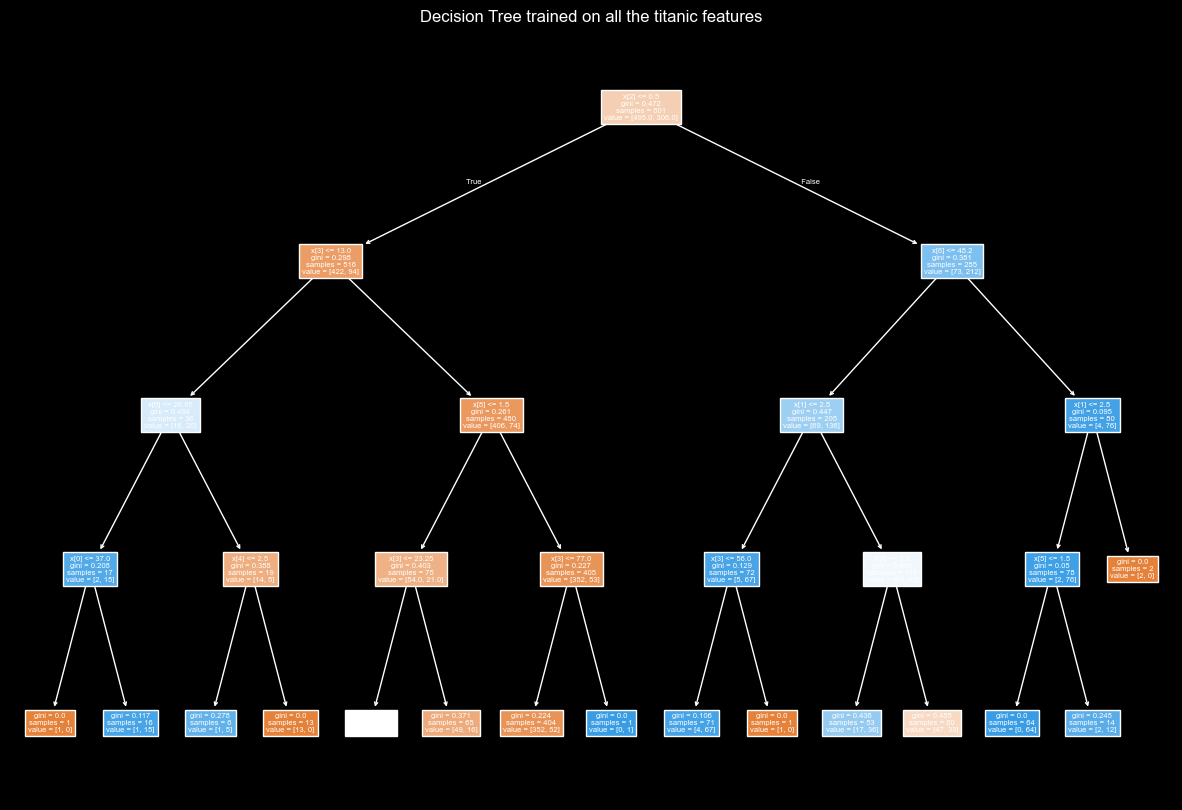

In [77]:
plot.figure(figsize=(15,10))
plot_tree(dtf,filled=True)
plot.title('Decision Tree trained on all the titanic features')
plot.show()

## Упражнения
1) Выполнить подбор оптимальных гиперпараметров RandomForest
2) Выполнить подбор оптимальных гиперпараметров для других моделей
3) Постройте ROC-кривые для моделей с оптимальными гиперпараметрами
4) Выполнить подбор оптимальных гиперпараметров для моделей на уменьшенном и увеличенном наборе признаков

In [78]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state=0)

param_grid_rfc = {
    'max_features':[None,'sqrt','log2'],
    'max_depth' : [4,5,6,7,8,10],
    'criterion':['gini','entropy','log_loss']
}

CV_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid_rfc, cv=8)
CV_rfc.fit(X, Y)

CV_rfc.best_params_

{'criterion': 'entropy', 'max_depth': 6, 'max_features': 'sqrt'}

In [79]:
from sklearn.linear_model import SGDClassifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

sgdc = SGDClassifier(random_state=0)

param_grid_sgdc = {
    'n_jobs' : [1,5,10,20,30],
    'max_iter': [1000,10000,2000],
    'random_state' : [0,5,10]
}

CV_sgdc = GridSearchCV(estimator=sgdc, param_grid=param_grid_sgdc, cv=8)
CV_sgdc.fit(X, Y)

CV_sgdc.best_params_

{'max_iter': 1000, 'n_jobs': 1, 'random_state': 5}

In [80]:
from sklearn.svm import LinearSVC
lsvc = LinearSVC(random_state=0)

param_grid_lsvc = {
    'max_iter': [1000,10000,2000],
    'random_state' : [0,5,10],
    'verbose': [0,1,2]
}

CV_lsvc = GridSearchCV(estimator=lsvc, param_grid=param_grid_lsvc, cv=8)
CV_lsvc.fit(X, Y)

CV_lsvc.best_params_

[LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear

{'max_iter': 1000, 'random_state': 0, 'verbose': 0}

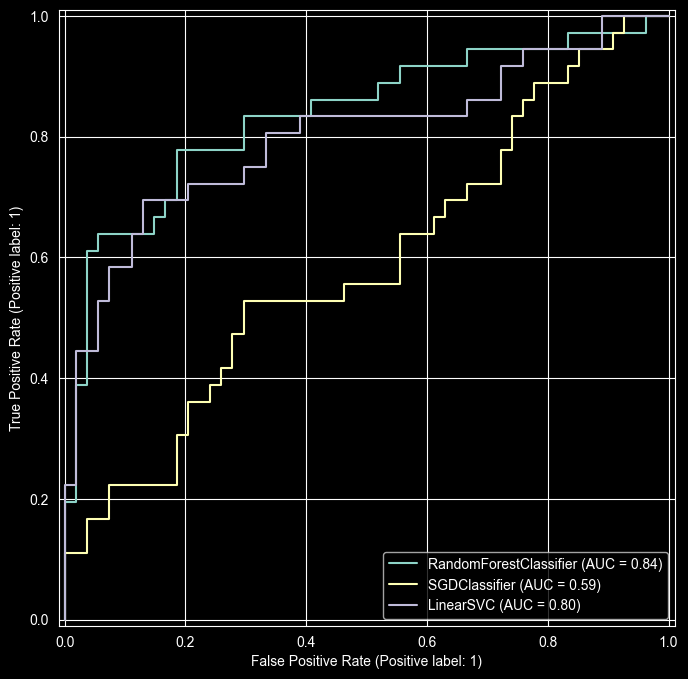

In [81]:
fig, ax = plot.subplots(figsize=(8,8))

rfc_perfect = RandomForestClassifier(criterion='entropy',max_depth=6,max_features='sqrt',random_state=0)
rfc_perfect.fit(X_train, Y_train)
RocCurveDisplay.from_estimator(rfc_perfect, X_test, Y_test,ax=ax)

sgdc_perfect = SGDClassifier(max_iter=1000,random_state=5,n_jobs=1)
sgdc_perfect.fit(X_train, Y_train)
RocCurveDisplay.from_estimator(sgdc_perfect, X_test, Y_test,ax=ax)

lsvc_perfect = LinearSVC(max_iter=1000,random_state=0,verbose=0)
lsvc_perfect.fit(X_train, Y_train)
RocCurveDisplay.from_estimator(lsvc_perfect, X_test, Y_test,ax=ax)

plot.show()



In [82]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state=0)

param_grid_rfc = {
    'max_features': [None, 'sqrt', 'log2'],
    'max_depth': [4, 5, 6, 7, 8, 10],
    'criterion': ['gini', 'entropy', 'log_loss']
}

CV_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid_rfc, cv=5)
CV_rfc.fit(X_fewer, Y)

CV_rfc.best_params_

{'criterion': 'entropy', 'max_depth': 7, 'max_features': None}

In [83]:

from sklearn.linear_model import SGDClassifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

sgdc = SGDClassifier(random_state=0)

param_grid_sgdc = {
    'n_jobs': [1, 5, 10, 20, 30],
    'max_iter': [1000, 10000, 2000],
    'random_state': [0, 5, 10]
}

CV_sgdc = GridSearchCV(estimator=sgdc, param_grid=param_grid_sgdc, cv=5)
CV_sgdc.fit(X_fewer, Y)

CV_sgdc.best_params_

{'max_iter': 1000, 'n_jobs': 1, 'random_state': 0}

In [84]:

from sklearn.svm import LinearSVC

lsvc = LinearSVC(random_state=0)

param_grid_lsvc = {
    'max_iter': [1000, 10000, 2000],
    'random_state': [0, 5, 10],
    'verbose': [0, 1, 2]
}

CV_lsvc = GridSearchCV(estimator=lsvc, param_grid=param_grid_lsvc, cv=5)
CV_lsvc.fit(X_fewer, Y)

CV_lsvc.best_params_

[LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear]

{'max_iter': 1000, 'random_state': 0, 'verbose': 0}

In [87]:

from sklearn.linear_model import SGDClassifier

from sklearn.neighbors import KNeighborsClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

sgdc = SGDClassifier(random_state=0)

param_grid_sgdc = {
    'n_jobs': [1, 5, 10, 20, 30],
    'max_iter': [1000, 10000, 2000],
    'random_state': [0, 5, 10]
}

CV_sgdc = GridSearchCV(estimator=sgdc, param_grid=param_grid_sgdc, cv=5)
CV_sgdc.fit(Xl, Y)

CV_sgdc.best_params_

{'max_iter': 1000, 'n_jobs': 1, 'random_state': 0}

In [88]:

from sklearn.svm import LinearSVC

lsvc = LinearSVC(random_state=0)

param_grid_lsvc = {
    'max_iter': [1000, 10000, 2000],
    'random_state': [0, 5, 10],
    'verbose': [0, 1, 2]
}

CV_lsvc = GridSearchCV(estimator=lsvc, param_grid=param_grid_lsvc, cv=5)
CV_lsvc.fit(Xl, Y)

CV_lsvc.best_params_

[LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear][LibLinear]

{'max_iter': 1000, 'random_state': 0, 'verbose': 0}

## Сделать randomized search для титаника (по примеру ирисов фишера)


In [92]:
from time import time

import numpy as np
import scipy.stats as stats

from sklearn.datasets import load_digits
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

#get some data
#X, y = load_digits(return_X_y=True,n_class=3)

#build a classifier


#utility
def report(results, n_top=3):
    for i in range(1,n_top+1):
        candidates = np.flatnonzero(results['rank_test_score'] == i)
        for candidate in candidates:
            print('Model with rank: {0}'.format(i))
            print(
                'Mean validation score: {0:.3f} (std: {1:.3f})'.format(results['mean_test_score'][candidate], results['std_test_score'][candidate])
            )
            print('Parametrs: {0}'.format(results['params'][candidate]))
            print('')




In [96]:
param_dist = {
    'average' : [True, False],
    'l1_ratio':stats.uniform(0,1),
    'alpha':stats.loguniform(1e-2,1e0),

}

clf = SGDClassifier()
#randomized search
n_iter_search = 50
random_search = RandomizedSearchCV(
    clf,param_distributions=param_dist,n_iter=n_iter_search
)

start = time()
random_search.fit(X_train,Y_train)
print(
    'RandomizedSearchCV took %.2f seconds for %d candidates parameter settings.'
    % (time() - start, n_iter_search)
)
report(random_search.cv_results_)

C:\Users\Daniil\PycharmProjects\CS351\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\Daniil\PycharmProjects\CS351\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
C:\Users\Daniil\PycharmProjects\CS351\.venv\Lib\site-packages\sklearn\linear_model\_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


RandomizedSearchCV took 2.58 seconds for 50 candidates parameter settings.
Model with rank: 1
Mean validation score: 0.718 (std: 0.035)
Parametrs: {'alpha': np.float64(0.03119875801950494), 'average': False, 'l1_ratio': np.float64(0.5580409374026136)}

Model with rank: 2
Mean validation score: 0.718 (std: 0.030)
Parametrs: {'alpha': np.float64(0.08613828388931188), 'average': False, 'l1_ratio': np.float64(0.2629830242060649)}

Model with rank: 3
Mean validation score: 0.693 (std: 0.028)
Parametrs: {'alpha': np.float64(0.024163228202816026), 'average': False, 'l1_ratio': np.float64(0.5461939815858388)}



In [114]:
param_dist = {
    'criterion' : ['gini', 'entropy','log_loss'],
    'splitter' : ['best', 'random'],
    'ccp_alpha':stats.loguniform(1.0,1e2),
    'min_samples_split' : stats.randint(2,100),
    'min_samples_leaf' : stats.randint(2,100),
}

dtc = DecisionTreeClassifier()
#randomized search
n_iter_search = 15
random_search = RandomizedSearchCV(
    dtc,param_distributions=param_dist,n_iter=n_iter_search
)

start = time()
random_search.fit(X_train,Y_train)
print(
    'RandomizedSearchCV took %.2f seconds for %d candidates parameter settings.'
    % (time() - start, n_iter_search)
)
report(random_search.cv_results_)

RandomizedSearchCV took 1.26 seconds for 15 candidates parameter settings.
Model with rank: 1
Mean validation score: 0.618 (std: 0.002)
Parametrs: {'ccp_alpha': np.float64(85.45400427604797), 'criterion': 'entropy', 'min_samples_leaf': 97, 'min_samples_split': 75, 'splitter': 'best'}

Model with rank: 1
Mean validation score: 0.618 (std: 0.002)
Parametrs: {'ccp_alpha': np.float64(79.25160566539822), 'criterion': 'gini', 'min_samples_leaf': 90, 'min_samples_split': 20, 'splitter': 'best'}

Model with rank: 1
Mean validation score: 0.618 (std: 0.002)
Parametrs: {'ccp_alpha': np.float64(3.166555498026556), 'criterion': 'entropy', 'min_samples_leaf': 33, 'min_samples_split': 75, 'splitter': 'random'}

Model with rank: 1
Mean validation score: 0.618 (std: 0.002)
Parametrs: {'ccp_alpha': np.float64(12.080001891867443), 'criterion': 'log_loss', 'min_samples_leaf': 86, 'min_samples_split': 67, 'splitter': 'best'}

Model with rank: 1
Mean validation score: 0.618 (std: 0.002)
Parametrs: {'ccp_al

In [117]:
from sklearn.svm import LinearSVC


param_dist = {
    'penalty' : ['l1', 'l2'],
    'tol': stats.loguniform(1e-4,1e-2),
    'intercept_scaling': stats.loguniform(1.0,1000.0),
}

lsvc = LinearSVC(random_state=0)
#randomized search
n_iter_search = 15
random_search = RandomizedSearchCV(
    lsvc,param_distributions=param_dist,n_iter=n_iter_search
)

start = time()
random_search.fit(X_train,Y_train)
print(
    'RandomizedSearchCV took %.2f seconds for %d candidates parameter settings.'
    % (time() - start, n_iter_search)
)
report(random_search.cv_results_)

RandomizedSearchCV took 1.64 seconds for 15 candidates parameter settings.
Model with rank: 1
Mean validation score: 0.799 (std: 0.042)
Parametrs: {'intercept_scaling': np.float64(123.65238353060856), 'penalty': 'l2', 'tol': np.float64(0.0059376559461802305)}

Model with rank: 2
Mean validation score: 0.799 (std: 0.044)
Parametrs: {'intercept_scaling': np.float64(8.070271251040031), 'penalty': 'l2', 'tol': np.float64(0.0021574264705058865)}

Model with rank: 3
Mean validation score: 0.798 (std: 0.050)
Parametrs: {'intercept_scaling': np.float64(3.0814606594642715), 'penalty': 'l2', 'tol': np.float64(0.0015441949555478405)}

